# **MÓDULO 27 - Projeto de Doenças Cardiovasculares - Regressão Logística**


Assim como na aula que trabalhamos com uma base de dados nova, com um contexto de modelo de propensão a compra de carros, para a atividade de vocês achei interessante trazer também novos desafios.

Nessa tarefa iremos construir um modelo que nos ajude a prever doenças cardiovasculares, a base contém dados reais.

age - idade dos pacientes

gender - genero (2 mulheres) (1 homens)

height - altura dos pacientes

weight - peso dos pacientes

gluc - glicose

smoke - fumante (1) não fumante (0)

alco - consume alcool (1) não consome (0)

active - realiza atividades fisicas (1) não realiza (0)

cardio_disease - tem doença cardio (1) não tem (0) - Variável target


Seu objetivo é utilizar esses dados históricos dos pacientes e construir um bom modelo de regressão capaz de indicar se novos pacientes estão propensos a doenças cariovasculares ou não.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, classification_report

# 1) Comece carregando e tratando a base de dados.
Assim como na aula essa nova base não passou por pré processamento nenhum então nessa etapa, carrega os dados, verifique os tipos de dados, verifique se temos dados faltantes e outliers.
Quando necessário realize o tratamento.


In [2]:
base = pd.read_csv("CARDIO_BASE.csv", delimiter=';')

In [3]:
# Olhando o Df
base

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
0,50,2,168,62,1,1,0,0,1,0
1,55,1,156,85,3,1,0,0,1,1
2,52,1,165,64,3,1,0,0,0,1
3,48,2,169,82,1,1,0,0,1,1
4,48,1,156,56,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
9995,56,1,166,65,1,1,0,0,0,0
9996,50,1,160,93,2,1,0,0,1,1
9997,40,1,158,66,2,2,0,0,1,0
9998,50,1,168,70,3,1,0,0,1,1


In [4]:
# Observar qualidade dos dados e presença de dados nulos
base.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             10000 non-null  int64
 1   gender          10000 non-null  int64
 2   height          10000 non-null  int64
 3   weight          10000 non-null  str  
 4   cholesterol     10000 non-null  int64
 5   gluc            10000 non-null  int64
 6   smoke           10000 non-null  int64
 7   alco            10000 non-null  int64
 8   active          10000 non-null  int64
 9   cardio_disease  10000 non-null  int64
dtypes: int64(9), str(1)
memory usage: 781.4 KB


In [5]:
# Alterar tipo da coluna weight porque está como categórica
base['weight'] = base['weight'].str.replace(',','.').astype(float)

base.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             10000 non-null  int64  
 1   gender          10000 non-null  int64  
 2   height          10000 non-null  int64  
 3   weight          10000 non-null  float64
 4   cholesterol     10000 non-null  int64  
 5   gluc            10000 non-null  int64  
 6   smoke           10000 non-null  int64  
 7   alco            10000 non-null  int64  
 8   active          10000 non-null  int64  
 9   cardio_disease  10000 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 781.4 KB


In [6]:
# Como não temos dados identificadores, vamos para a descrição estatística dos dados
base.describe()

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,53.288300,1.345400,164.308200,74.303710,1.365000,1.222200,0.089000,0.053700,0.797200,0.503100
std,6.796234,0.475522,8.178796,14.566353,0.677658,0.565561,0.284758,0.225436,0.402105,0.500015
min,30.000000,1.000000,70.000000,30.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,65.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,165.000000,72.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
75%,58.000000,2.000000,170.000000,82.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,65.000000,2.000000,250.000000,200.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
# Usando o Boxplot para identificar possíveis outliers
fig = go.Figure()
fig.add_trace(go.Box(y = base['weight'],
                     name = 'Weight',
                     boxpoints = 'suspectedoutliers',
                     marker = dict(color = 'lightblue',
                                 outliercolor = 'gold')))
fig.add_trace(go.Box(y = base['height'],
                     name = 'Height',
                     boxpoints = 'suspectedoutliers',
                     marker = dict(color = 'lightgreen',
                                 outliercolor = 'gold')))

fig.show()

In [8]:
# usando zscores para tratar possíveis outliers detectados
from scipy import stats
import numpy as np

z_scores = np.abs(stats.zscore(base[['height', 'weight']]))
limite = 3

base_tratada = base[(z_scores < limite).all(axis=1)]

# plotando o gráfico novamente para ver as diferenças
fig = go.Figure()
fig.add_trace(go.Box(y = base_tratada['weight'],
                     name = 'Weight',
                     boxpoints = 'suspectedoutliers',
                     marker = dict(color = 'lightblue',
                                 outliercolor = 'gold')))
fig.add_trace(go.Box(y = base_tratada['height'],
                     name = 'Height',
                     boxpoints = 'suspectedoutliers',
                     marker = dict(color = 'lightgreen',
                                 outliercolor = 'gold')))

fig.show()

In [9]:
base_tratada.describe()

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
count,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000,9858.000000
mean,53.305031,1.343477,164.284033,73.690820,1.363968,1.221039,0.088253,0.053459,0.797423,0.501116
std,6.795016,0.474893,7.678528,13.253689,0.676875,0.564349,0.283677,0.224959,0.401940,0.500024
min,30.000000,1.000000,140.000000,37.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,65.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,165.000000,72.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
75%,58.000000,2.000000,170.000000,82.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,65.000000,2.000000,188.000000,118.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


# 2) Agora é hora de explorar os dados com uma análise bem completa.
Plote pelo menos 3 gráficos analisando o comportamento da variável cardio com outras variaveis da sua preferência (análise bivariada). Não se esqueça de trazer insights acerca do analisado.


In [19]:
# Análises do comportamento das seguintes colunas (weight, smoke, alco) com a coluna cárdio
# Relação entre peso e cárdio
import plotly.express as px
car_wei = base_tratada.groupby('weight')['cardio_disease'].value_counts().reset_index()
fig = px.histogram(car_wei,
                   y = 'count',
                   x = 'weight',
                   color = 'cardio_disease',
                   color_discrete_map = {1: '#c7c3c3', 0: '#424040'},
                   labels ={'cardio_disease':'Doença cardíaca'})
fig.for_each_trace(
    lambda t: t.update(name = 'Sim' if t.name == '1' else 'Não')
)
fig.update_layout(
    yaxis_title = 'Contagem',
    xaxis_title = 'Peso',
    title = 'Contagem de doenças cardíacas X Peso'
)
fig.show()

Baseado no gráfico acima parece existir uma correlação entre peso e a presença de doenças cardíacas, uma vez que sua contagem aumenta, se comparado com a ausência, a partir da faixa entre 65 e 75.

In [40]:
# Relação entre consumo de cigarro, alcool e doenças cardíacas
car_alco = base_tratada.groupby('alco')['cardio_disease'].value_counts(normalize = True).rename('proporcao').reset_index()
fig = px.bar(car_alco,
                   y = 'proporcao',
                   x = 'alco',
                   color = 'cardio_disease',
                    color_continuous_scale=px.colors.sequential.Agsunset,
                   labels ={'cardio_disease':'Doença cardíaca'},
                   text_auto = '.2%')
fig.for_each_trace(
    lambda t: t.update(name = 'Sim' if t.name == '1' else 'Não')
)
fig.update_layout(
    yaxis_title = 'Proporção',
    xaxis = dict(
        title='Consumo de Álcool',
        tickvals=[0, 1],
        ticktext=['Não', 'Sim']),
    title = 'Proporção de doenças cardíacas X consumo de álcool'
)
fig.show()

A análise mostra que o consumo de álcool não demonstra uma correlação com a presença de doenças cardíacas.

In [41]:
car_smo = base_tratada.groupby('smoke')['cardio_disease'].value_counts(normalize = True).rename('proporcao').reset_index()
fig = px.bar(car_smo,
                   y = 'proporcao',
                   x = 'smoke',
                   color = 'cardio_disease',
                    color_continuous_scale=px.colors.sequential.algae,
                   labels ={'cardio_disease':'Doença cardíaca'},
                   text_auto = '.2%')
fig.for_each_trace(
    lambda t: t.update(name = 'Sim' if t.name == '1' else 'Não')
)
fig.update_layout(
    yaxis_title = 'Proporção',
    xaxis = dict(
        title='Consumo de Cigarros',
        tickvals=[0, 1],
        ticktext=['Não', 'Sim']),
    title = 'Proporção de doenças cardíacas X consumo de cigarros'
)
fig.show()

A análise demonstrou não haver uma correlação clara entre o consumo de cigarros e a presença de doenças cardíacas

# 3) Nessa etapa você deve trazer a matriz de correlação e apontar insights acerca das variáveis com um relacionamento mais forte entre si.



In [42]:
# gerando a matriz de correlação
corr = base_tratada.corr()
fig = px.imshow(
    corr,
    text_auto = True,
    aspect='auto',
    color_continuous_scale=px.colors.diverging.Armyrose,
)
fig.show()

A matriz de correlação demonstra que nenhuma variável tem correlação positiva forte com a presença de doenças cardíacas, apesar de que a idade, colesterol alto e peso obterem os maiores valores na análise.



# 4) Essa é a sua última etapa pré modelo. Você deve:

A) Separar a base em treino e teste.

B) Você considera que essa base precisa que os dados sejam padronizados? Se sim, porque? Se acredita que devem, então realize essa etapa.

C) Verifique se os dados estão balanceados, se não, faça o balanceamento.


D) Visualize as bases de treino, teste (X E Y) e verifique se está tudo adequado.

Eu acredito que as colunas, idade, altura e peso devem ser padronizadas por terem valores em escalas diferentes das demais colunas (que apresentam dados variando entre 0 e 1). A padronização deve auxiliar o modelo a ser mais preciso.

In [43]:
# Separando a base em X e Y
X = base_tratada.drop('cardio_disease', axis = 1)
Y = base_tratada['cardio_disease']

In [44]:
# Verificando balanceamento
base_tratada['cardio_disease'].value_counts()

cardio_disease
1    4940
0    4918
Name: count, dtype: int64

In [45]:
# Separando as bases em treino e teste
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [46]:
# Padronizando as colunas
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [47]:
# Como existe um leve desbalanceamento, vou balancear os dados de treino
smote = SMOTE(random_state=42)
X_train_bal, Y_train_bal = smote.fit_resample(X_train, Y_train)

In [48]:
X_train_bal

array([[ 1.5652225 , -0.72073608, -1.33712889, ..., -0.30471171,
        -0.23418403,  0.50352438],
       [-1.5178609 ,  1.38747043,  0.22285756, ..., -0.30471171,
        -0.23418403,  0.50352438],
       [ 1.71203599, -0.72073608,  0.4828553 , ..., -0.30471171,
        -0.23418403, -1.98600116],
       ...,
       [-0.49016644, -0.72073608,  0.08849876, ..., -0.30471171,
        -0.23418403,  0.50352438],
       [-1.07742042, -0.72073608,  0.22285756, ..., -0.30471171,
        -0.23418403,  0.50352438],
       [-1.68523704,  1.38747043,  2.62000575, ..., -0.30471171,
        -0.23418403, -1.98600116]], shape=(7902, 9))

In [49]:
Y_train_bal

0       1
1       0
2       1
3       1
4       1
       ..
7897    0
7898    0
7899    0
7900    0
7901    0
Name: cardio_disease, Length: 7902, dtype: int64

In [50]:
X_test

array([[ 0.68434153,  1.38747043,  0.61285417, ..., -0.30471171,
        -0.23418403,  0.50352438],
       [ 0.39071454, -0.72073608, -0.8171334 , ..., -0.30471171,
        -0.23418403,  0.50352438],
       [ 0.39071454, -0.72073608, -0.03714018, ..., -0.30471171,
        -0.23418403,  0.50352438],
       ...,
       [-1.6646744 , -0.72073608, -0.94713227, ..., -0.30471171,
        -0.23418403,  0.50352438],
       [-1.07742042, -0.72073608, -0.55713566, ..., -0.30471171,
        -0.23418403,  0.50352438],
       [ 1.27159551,  1.38747043, -0.42713679, ..., -0.30471171,
        -0.23418403,  0.50352438]], shape=(1972, 9))

In [51]:
Y_test

8493    1
505     1
5152    1
881     1
8849    0
       ..
7237    1
6779    0
2302    0
1909    1
4660    0
Name: cardio_disease, Length: 1972, dtype: int64

# 5) Realize a etapa de treinamento do modelo:

A) Faça o treinamento do modelo.

B) Traga o intercept e os coeficientes.

c) Avalie as métricas do modelo treinado

D) Justifique se te parece que o modelo tem feito boas previsões ou não.

In [52]:
# Realizando o treinamento do modelo
log_cardio = LogisticRegression(random_state=0)

log_cardio.fit(X_train_bal, Y_train_bal)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [53]:
log_cardio.intercept_

array([0.01410593])

In [54]:
log_cardio.coef_

array([[ 0.42770945,  0.00737902, -0.09751313,  0.36564425,  0.40615764,
        -0.06581637, -0.01811112, -0.01952637, -0.08986309]])

In [56]:
previsoes = log_cardio.predict(X_train_bal)

relatorio = classification_report(Y_train_bal, previsoes)
print(f'Classificacao:\n {relatorio}')

Classificacao:
               precision    recall  f1-score   support

           0       0.63      0.67      0.65      3951
           1       0.64      0.61      0.63      3951

    accuracy                           0.64      7902
   macro avg       0.64      0.64      0.64      7902
weighted avg       0.64      0.64      0.64      7902



Como os dados de precisão para o treino ficaram em torno de 65% eu não consideraria esse modelo confiável para o que precisamos classificar. Isso se deve pelo fato das correlações não terem se mostrado fortes o suficiente para o estabelecimento do modelo.

# 6) Teste seu modelo!

A) Aplique o modelo aos dados de teste.

B) Avalie as métricas do modelo treinado

C) Plote o gráfico da curva AUC-ROC e explique o que consegue analisar através do gráfico.

In [57]:
# Aplicando o teste
Y_pred_test = log_cardio.predict(X_test)

relatorio = classification_report(Y_test, Y_pred_test)
print(f'Classificacao:\n {relatorio}')

Classificacao:
               precision    recall  f1-score   support

           0       0.63      0.67      0.65       983
           1       0.65      0.61      0.63       989

    accuracy                           0.64      1972
   macro avg       0.64      0.64      0.64      1972
weighted avg       0.64      0.64      0.64      1972



A precisão do modelo na fase de teste se aproxima muito da fase de treino. Isso pode significar que a padronização e o balanceamento dos dados contribuíram para o desempenho do modelo.

In [58]:
# Curva AUC-ROC
from sklearn.metrics import roc_curve, roc_auc_score, classification_report
fpr, tpr, tresholds = roc_curve(Y_test, Y_pred_test)

roc_auc = roc_auc_score(Y_test, Y_pred_test)
print("AUC: {:.2f}".format(roc_auc))

AUC: 0.64


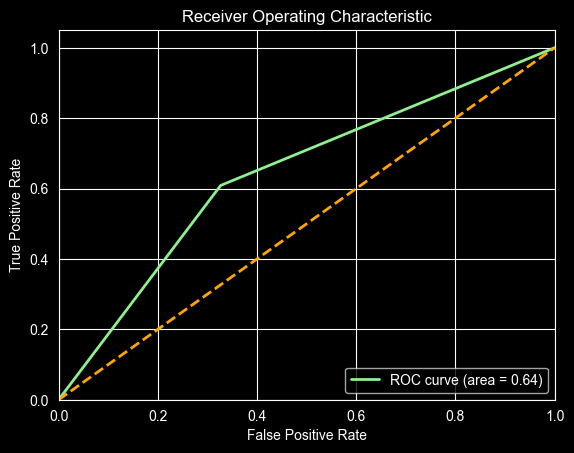

In [63]:
plt.figure()
plt.plot(fpr, tpr, color='lightgreen', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='orange', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# 7) Explique:

A) Explique com suas palavras regressão logistica.

B) Explique porque a regressão logistica é um modelo de classificação.

C) Explique quais pontos em comum a regressão logistica tem da regressão linear.



A regressão logística é um modelo de classificação usado para separar eventos com base na sua probabilidade. Ela aplica a função sigmóide para transformar valores reais em números entre 0 e 1.

A regressão logística é um modelo de classificação porque separa dados em classes a partir da função sigmóide aplicada à regressão linear. Após obter os valores ela separa os resultados classificando-os.

Apesar da regressão linear ter como resultado valores contínuos e ser usado como modelo de previsão, ele é o primeiro passo para que a regressão logística possa utilizar a função sigmóide e classificar os resultados.